### Классификационное дерево и Random Forest

**Классификационное дерево** - это алгоритм машинного обучения, который строит иерархическую структуру вопросов о признаках данных, где каждый вопрос разделяет данные на ветви, а конечные узлы содержат ответы - предсказанные классы.


**Random Forest** - это ансамблевый метод, который создает множество деревьев решений, каждое из которых обучается на случайной подвыборке данных и случайном подмножестве признаков, а итоговый прогноз получается путем голосования всех деревьев. Такой подход значительно снижает риск переобучения.

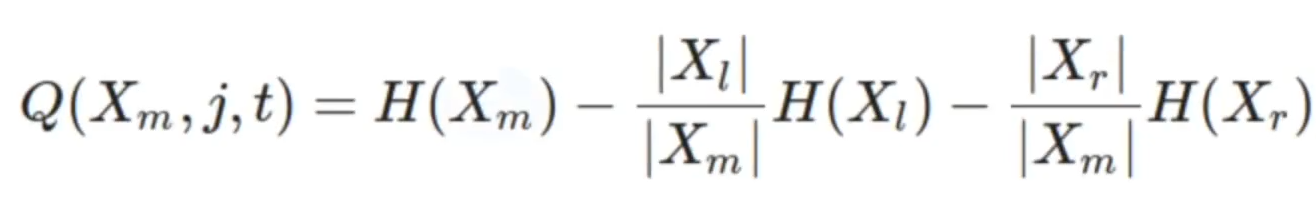

# Энтропия Шеннона

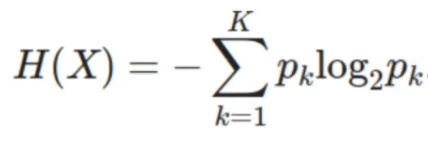

# Критерий Джини

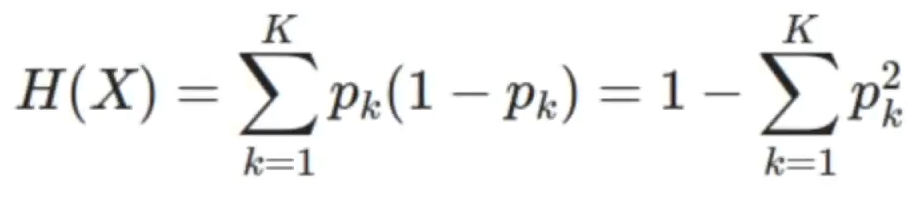

## Используемые библиотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## Используемый датасет

Размер матрицы признаков: (70000, 784)
Количество примеров: 70000
Количество признаков (пикселей): 784
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]



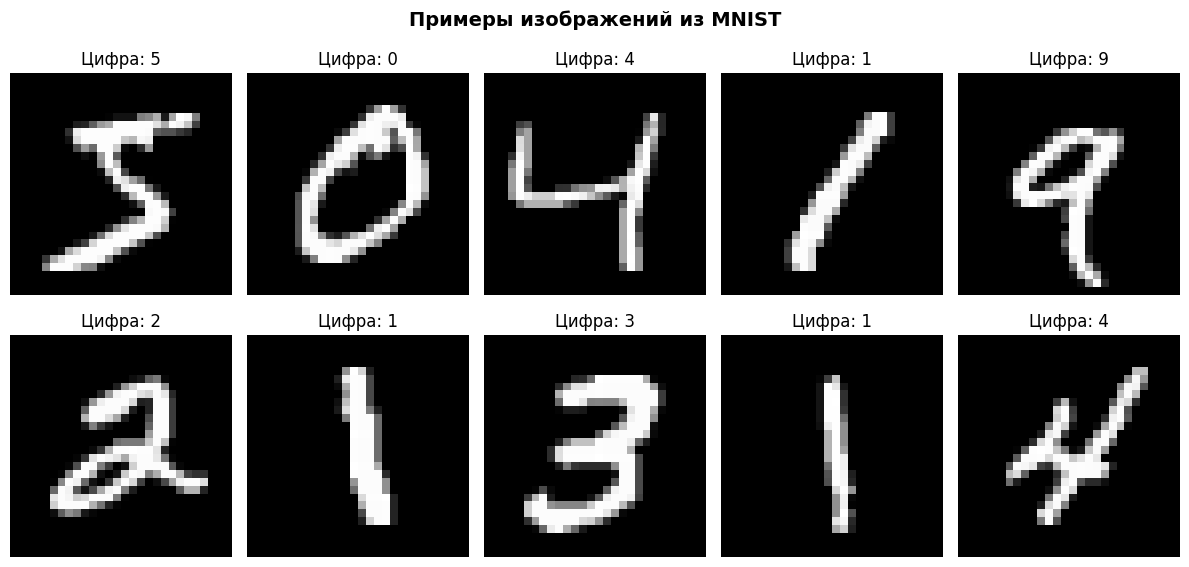

In [2]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data.values, mnist.target.astype(int).values

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество примеров: {len(X)}")
print(f"Количество признаков (пикселей): {X.shape[1]}")
print(f"Уникальные классы: {np.unique(y)}")
print()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Цифра: {y[i]}")
    axes[i].axis('off')

plt.suptitle("Примеры изображений из MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Обработка датасета

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} примеров")
print(f"Размер тестовой выборки: {X_test.shape[0]} примеров")

Размер обучающей выборки: 56000 примеров
Размер тестовой выборки: 14000 примеров


## Тепловая карта

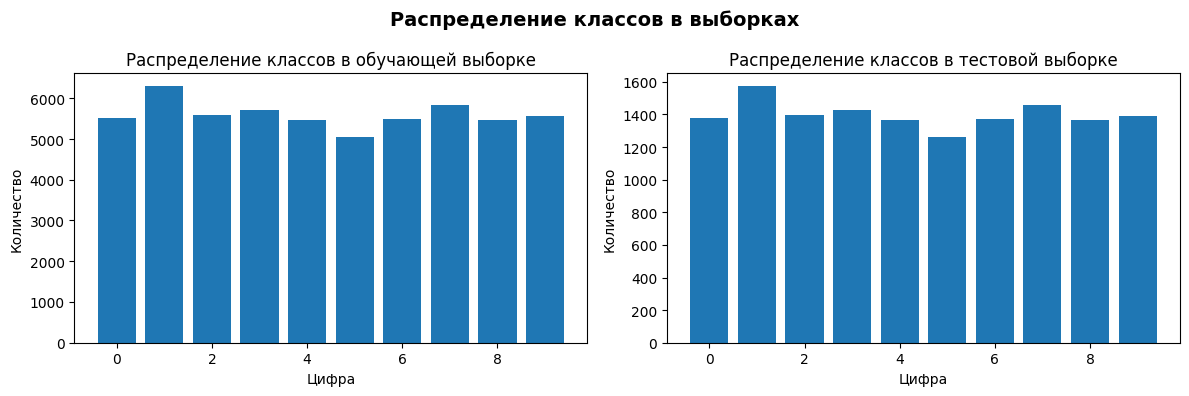

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(unique_train, counts_train)
axes[0].set_title('Распределение классов в обучающей выборке')
axes[0].set_xlabel('Цифра')
axes[0].set_ylabel('Количество')

unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(unique_test, counts_test)
axes[1].set_title('Распределение классов в тестовой выборке')
axes[1].set_xlabel('Цифра')
axes[1].set_ylabel('Количество')

plt.suptitle("Распределение классов в выборках", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Обучение модели

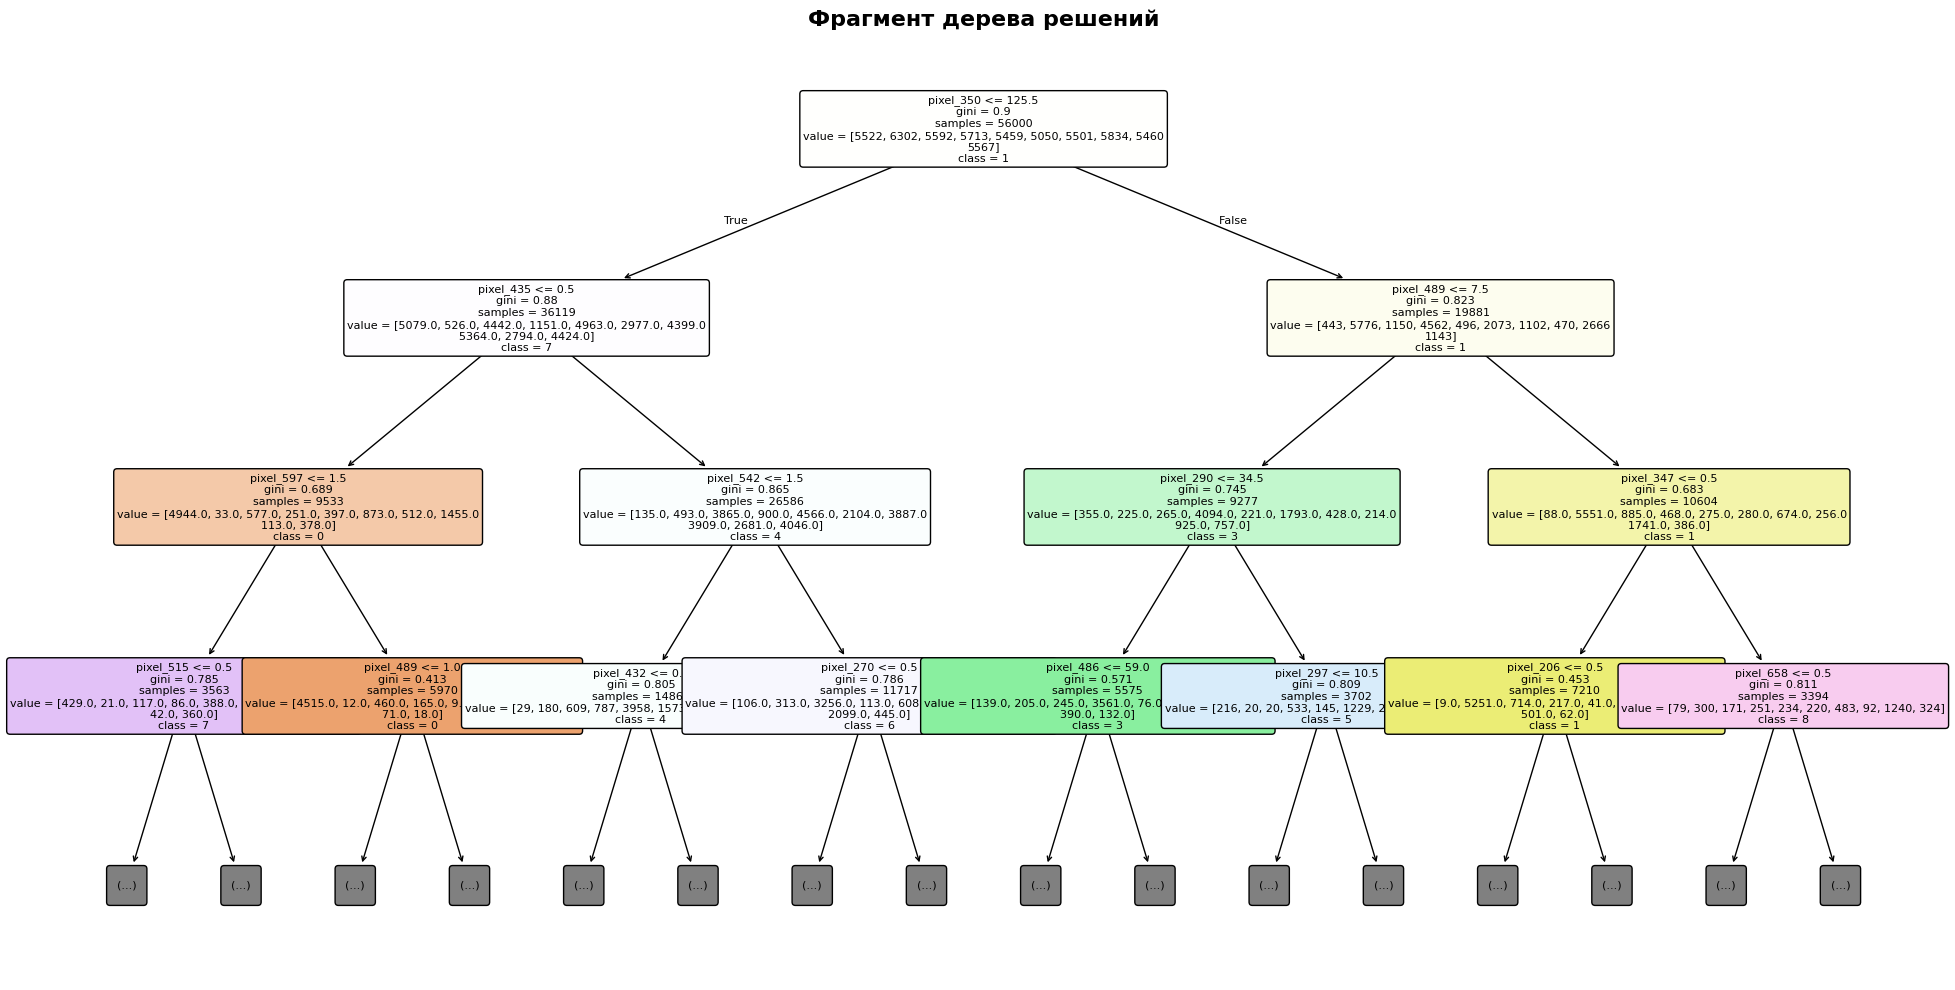

In [9]:
dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          max_depth=3,
          feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
          class_names=[str(i) for i in range(10)],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Фрагмент дерева решений", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print()


## Прогнозы модели

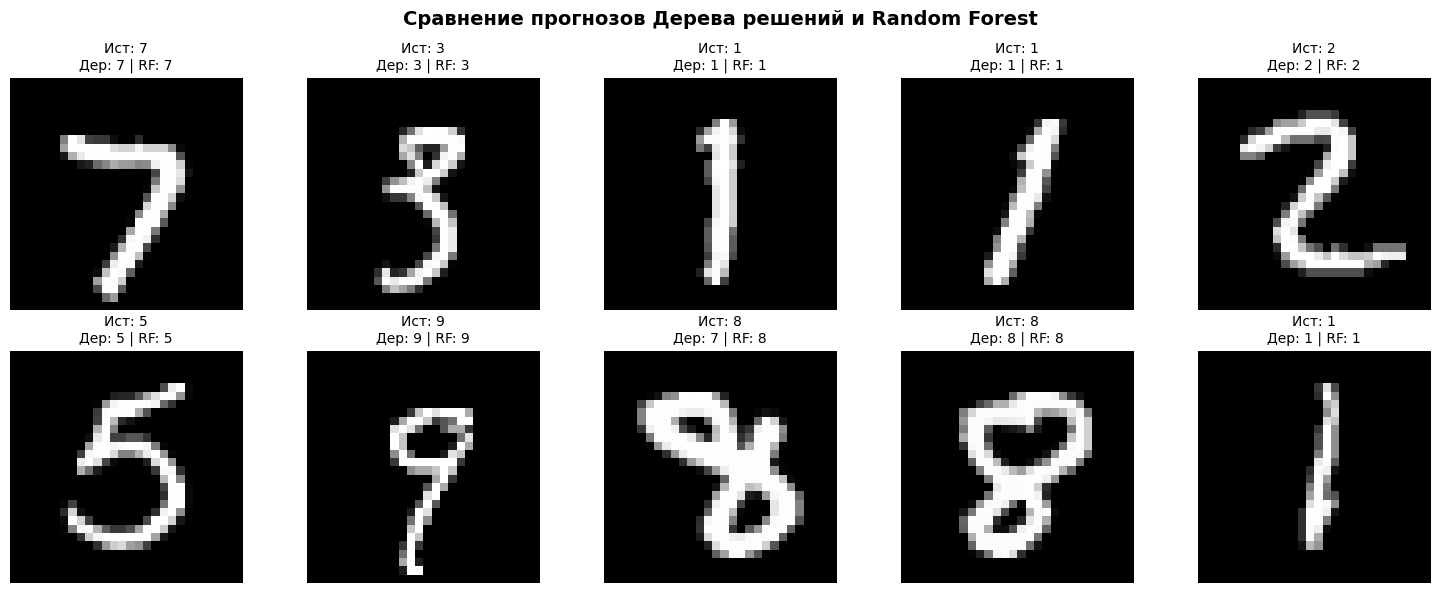

In [10]:
dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Ист: {y_test[i]}\nДер: {dt_predictions[i]} | RF: {rf_predictions[i]}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Сравнение прогнозов Дерева решений и Random Forest",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()


## Графики выходных результатов

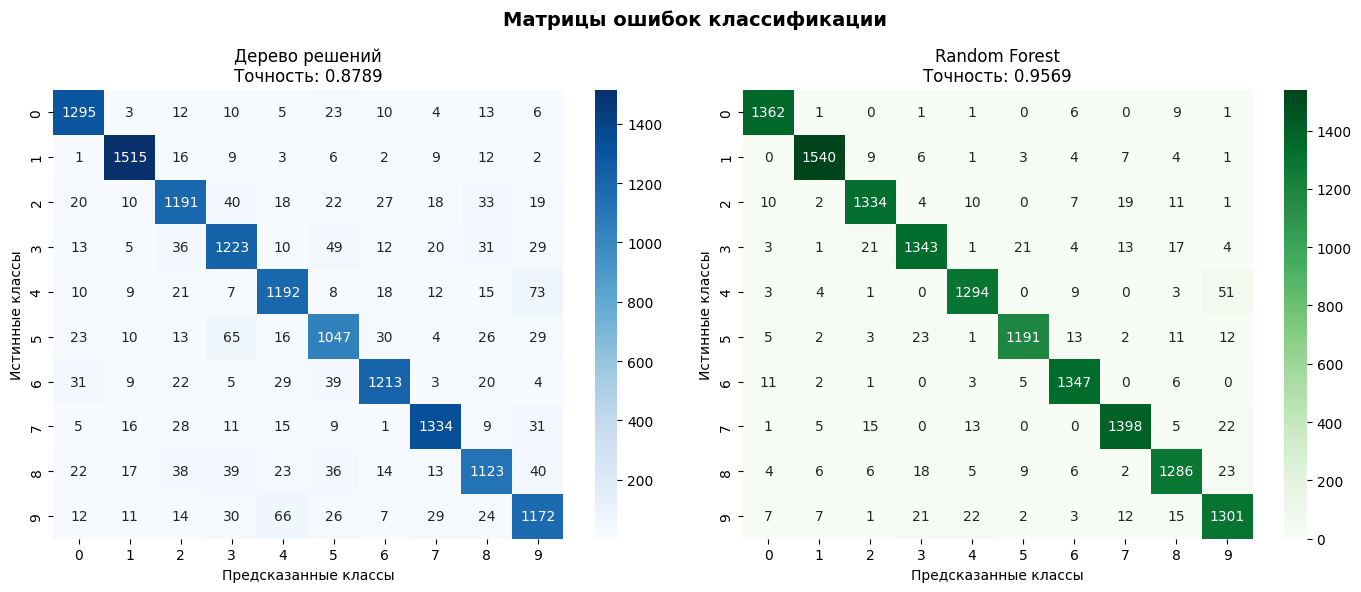

In [11]:
dt_accuracy = accuracy_score(y_test, dt_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

dt_cm = confusion_matrix(y_test, dt_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title(f'Дерево решений\nТочность: {dt_accuracy:.4f}', fontsize=12)
axes[0].set_xlabel('Предсказанные классы')
axes[0].set_ylabel('Истинные классы')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title(f'Random Forest\nТочность: {rf_accuracy:.4f}', fontsize=12)
axes[1].set_xlabel('Предсказанные классы')
axes[1].set_ylabel('Истинные классы')

plt.suptitle("Матрицы ошибок классификации", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

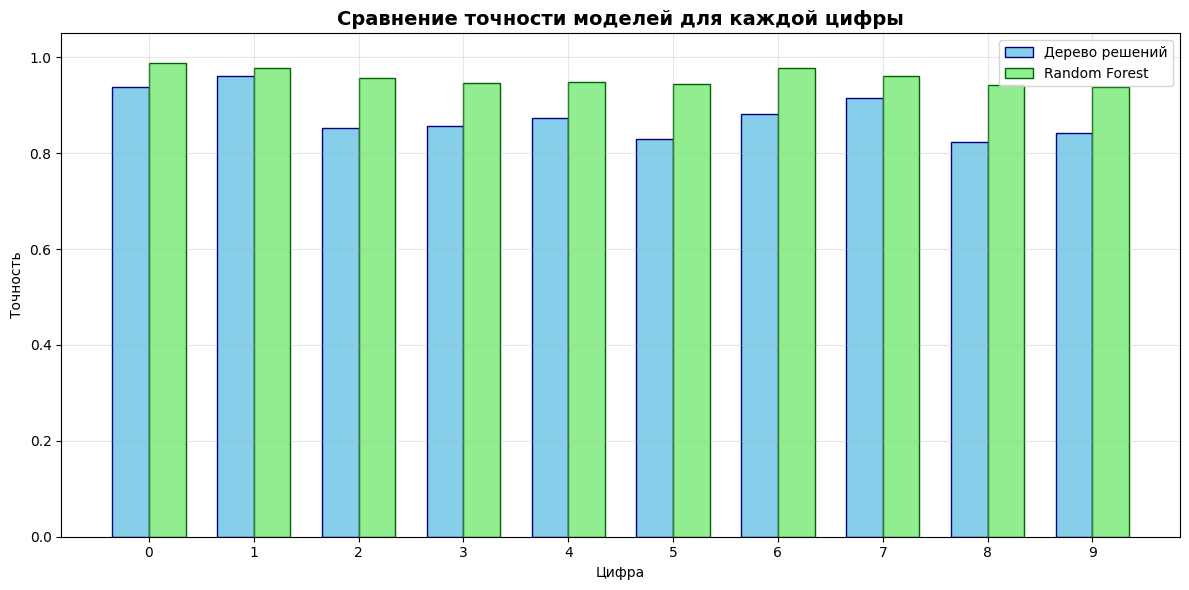

In [8]:
dt_per_digit = []
rf_per_digit = []

for digit in range(10):
    digit_mask = (y_test == digit)
    dt_digit_acc = accuracy_score(y_test[digit_mask], dt_predictions[digit_mask])
    rf_digit_acc = accuracy_score(y_test[digit_mask], rf_predictions[digit_mask])
    dt_per_digit.append(dt_digit_acc)
    rf_per_digit.append(rf_digit_acc)

plt.figure(figsize=(12, 6))
x = np.arange(10)
width = 0.35

plt.bar(x - width / 2, dt_per_digit, width, label='Дерево решений', color='skyblue', edgecolor='navy')
plt.bar(x + width / 2, rf_per_digit, width, label='Random Forest', color='lightgreen', edgecolor='darkgreen')

plt.xlabel('Цифра')
plt.ylabel('Точность')
plt.title('Сравнение точности моделей для каждой цифры', fontsize=14, fontweight='bold')
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()